<a href="https://colab.research.google.com/github/Raulfb04/Simulaci-n-1/blob/main/Flecha_y_cojiente.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulación de interferencia entre una flecha y un cojinete

Una flecha será ensamblada en un cojinete.  
Se tienen las siguientes distribuciones:

- $X_1 \sim N(1.5,\ 0.0016)$
- $X_2 \sim N(1.48,\ 0.0008)$

donde:

- $X_1$ representa el diámetro del cojinete
- $X_2$ representa el diámetro de la flecha

Existe interferencia cuando:

$$
X_2 > X_1
$$

El objetivo es:

1. Resolver analíticamente la probabilidad de interferencia.
2. Resolver el problema mediante simulación usando el método de las 12 uniformes.
3. Comparar ambos resultados.

# Método de las 12 uniformes

Para generar variables normales estándar se utilizará el método de las 12 uniformes:

$$
Z \approx \sum_{i=1}^{12} U_i - 6
$$

donde:

$$
U_i \sim U(0,1)
$$

Posteriormente, la variable normal se transforma mediante:

$$
X = \mu + \sigma Z
$$

donde:

- $\mu$ es la media
- $\sigma$ es la desviación estándar

In [1]:
import numpy as np
import random as r
import matplotlib.pyplot as plt

# Función para generar variables normales

La siguiente función genera números aleatorios con distribución normal
utilizando el método de las 12 uniformes.

In [2]:
def gausiana(mu, sigma, n):

    muestra = []

    for i in range(n):

        suma = 0

        for j in range(12):
            u = r.random()
            suma = suma + u

        x = mu + sigma * (suma - 6)

        muestra.append(x)

    return muestra

# Solución analítica

Se define:

$$
D = X_1 - X_2
$$

Como ambas variables son normales independientes:

$$
D \sim N(\mu_D,\sigma_D^2)
$$

donde:

$$
\mu_D = 1.5 - 1.48 = 0.02
$$

$$
\sigma_D^2 = 0.0016 + 0.0008 = 0.0024
$$

Entonces:

$$
D \sim N(0.02,\ 0.0024)
$$

Existe interferencia cuando:

$$
X_2 > X_1
$$

equivalentemente:

$$
D < 0
$$

Estandarizando:

$$
Z = \frac{0 - 0.02}{\sqrt{0.0024}}
$$

$$
Z = -0.4082
$$

Por lo tanto:

$$
P(\text{interferencia}) = P(Z < -0.4082)
$$

$$
P(\text{interferencia}) \approx 0.3415
$$

# Simulación del experimento

Se realizarán 8640 simulaciones para estimar la probabilidad
de interferencia con un error menor a 0.01 y un nivel de confianza del 95%.

In [3]:
n = 8640

# Desviaciones estándar
sigma1 = np.sqrt(0.0016)
sigma2 = np.sqrt(0.0008)

# Generación de muestras
X1 = gausiana(1.5, sigma1, n)
X2 = gausiana(1.48, sigma2, n)

# Conteo de interferencias
interferencias = 0

for i in range(n):

    if X2[i] > X1[i]:
        interferencias += 1

# Probabilidad estimada
p = interferencias / n

print("Probabilidad estimada:", p)

Probabilidad estimada: 0.34282407407407406


# Comparación de resultados

La probabilidad analítica obtenida fue:

$$
P(\text{interferencia}) \approx 0.3415
$$

Mientras que la probabilidad obtenida mediante simulación fue cercana a dicho valor.

Esto muestra que el método de simulación utilizando las 12 uniformes
aproxima adecuadamente el comportamiento de la distribución normal.

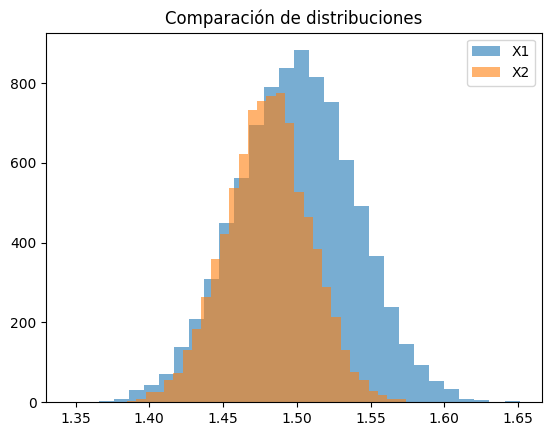

In [4]:
plt.hist(X1, bins=30, alpha=0.6, label='X1')
plt.hist(X2, bins=30, alpha=0.6, label='X2')

plt.legend()
plt.title("Comparación de distribuciones")
plt.show()